## Libraries and Data

In [1]:
# Import Libraries

import pandas as pd
import numpy as np

from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import joblib

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Set File Paths

DATA_DIR = Path("../data")
MODEL_DIR = Path("../models")

MODEL_DIR.mkdir(exist_ok=True)

In [3]:
# Load Dataset

energy_df = pd.read_csv(DATA_DIR / "processed" / "energy_household_with_target_step3.csv")

print("Dataset loaded successfully!")
print("Shape:", energy_df.shape)

energy_df.head()

Dataset loaded successfully!
Shape: (3599, 59)


,hhid,zone,state,lga,urca_cat,adult_count,members_under_18,members_18_30,members_31_55,members_over_55,...,electric_cooker_monthly_kwh,thermal_appliance_monthly_kwh,air_cooler_monthly_kwh,estimated_monthly_kwh,supply_factor,estimated_monthly_kwh_adjusted,consumption_category,log_estimated_monthly_kwh,estimated_monthly_kwh_raw,outlier_flag
0,d8af8ab5-30ab-4d9f-bfe4-81231dbe5dbf,North Central,Niger,mashegu,<1hr to small city/town+,5,13,4,1,0,...,0.0,18.0,0.0,39.3000,0.200000,39.300,High Consumption,3.696351,39.300,0
1,e8245d5c-8130-4e78-b4b0-1053b7ecbc9b,North Central,Niger,mashegu,<1hr to small city/town+,6,4,3,2,1,...,0.0,0.0,0.0,12.3750,0.250000,12.375,Moderate Consumption,2.593387,12.375,0
2,435c8e27-517a-46b9-af04-48830e086d7a,North West,Kano,garun_malam,<1hr to large city,3,3,2,1,0,...,0.0,18.0,0.0,51.2250,0.500000,51.225,Very High Consumption,3.955561,51.225,0
3,9303fa53-9fd2-41a9-9f0d-9567dbe5168e,North West,Kano,garun_malam,<1hr to large city,3,7,2,1,0,...,0.0,18.0,12.0,153.2325,0.500000,157.200,Very High Consumption,5.063860,157.200,1
4,c62cc5a5-29c5-423b-9543-a7b05bda454b,North West,Kano,garun_malam,<1hr to large city,2,4,1,1,0,...,0.0,18.0,0.0,4.8750,0.208333,4.875,Moderate Consumption,1.770706,4.875,0


In [4]:
# Check Target Column

print("Target column summary:")
print(energy_df['estimated_monthly_kwh'].describe())

print("\nMissing target values:")
print(energy_df['estimated_monthly_kwh'].isnull().sum())

Target column summary:
count    3599.000000
mean       35.872091
std        42.554598
min         0.000000
25%         4.800000
50%        19.162500
75%        49.612500
max       153.232500
Name: estimated_monthly_kwh, dtype: float64

Missing target values:
0


## Create and Select Features

##### Create Improved App-Friendly Features

In [22]:
# Create Improved App-Friendly Features

energy_df = pd.read_csv(DATA_DIR / "processed" / "energy_household_with_target_step3.csv")

# AC usage assumption
energy_df['average_ac_usage_hours'] = np.where(
    energy_df['ac_count'] > 0,
    4,
    0
)

# Basic app input features
basic_features = [
    'household_size',
    'number_of_rooms',
    'daily_supply_hours',
    'light_bulb_count',
    'fan_count',
    'television_count',
    'fridge_count',
    'ac_count',
    'average_ac_usage_hours'
]

# Behind-the-scenes engineered features
energy_df['bulb_energy_proxy'] = (
    energy_df['light_bulb_count'] * np.minimum(energy_df['daily_supply_hours'], 6)
)

energy_df['fan_energy_proxy'] = (
    energy_df['fan_count'] * np.minimum(energy_df['daily_supply_hours'], 8)
)

energy_df['tv_energy_proxy'] = (
    energy_df['television_count'] * np.minimum(energy_df['daily_supply_hours'], 4)
)

energy_df['fridge_energy_proxy'] = (
    energy_df['fridge_count'] * 12
)

energy_df['ac_energy_proxy'] = (
    energy_df['ac_count'] * energy_df['average_ac_usage_hours']
)

energy_df['total_selected_appliances'] = (
    energy_df['light_bulb_count'] +
    energy_df['fan_count'] +
    energy_df['television_count'] +
    energy_df['fridge_count'] +
    energy_df['ac_count']
)

energy_df['cooling_appliance_count'] = (
    energy_df['fan_count'] +
    energy_df['ac_count']
)

energy_df['room_person_ratio'] = (
    energy_df['number_of_rooms'] / energy_df['household_size'].replace(0, np.nan)
)

engineered_features = [
    'bulb_energy_proxy',
    'fan_energy_proxy',
    'tv_energy_proxy',
    'fridge_energy_proxy',
    'ac_energy_proxy',
    'total_selected_appliances',
    'cooling_appliance_count',
    'room_person_ratio'
]

model_features = basic_features + engineered_features

target_column = 'estimated_monthly_kwh'

model_df = energy_df[model_features + [target_column]].copy()

model_df = model_df.replace([np.inf, -np.inf], np.nan)
model_df = model_df.dropna()

print("Improved modelling dataset shape:", model_df.shape)

model_df.head()

Improved modelling dataset shape: (3599, 18)


,household_size,number_of_rooms,daily_supply_hours,light_bulb_count,fan_count,television_count,fridge_count,ac_count,average_ac_usage_hours,bulb_energy_proxy,fan_energy_proxy,tv_energy_proxy,fridge_energy_proxy,ac_energy_proxy,total_selected_appliances,cooling_appliance_count,room_person_ratio,estimated_monthly_kwh
0,18,8,4.0,15,8,2,1,0,0,60.0,32.0,8.0,12,0,26,8,0.444444,39.3000
1,10,9,6.0,12,1,1,0,0,0,72.0,6.0,4.0,0,0,14,1,0.900000,12.3750
2,6,5,12.0,6,2,1,0,0,0,36.0,16.0,4.0,0,0,9,2,0.833333,51.2250
3,10,10,12.0,20,6,1,1,0,0,120.0,48.0,4.0,12,0,28,6,1.000000,153.2325
4,6,3,5.0,3,0,0,0,0,0,15.0,0.0,0.0,0,0,3,0,0.500000,4.8750


In [23]:
# Define Features and Target

X = model_df[model_features]
y = model_df[target_column]

print("Feature data shape:", X.shape)
print("Target data shape:", y.shape)

Feature data shape: (3599, 17)
Target data shape: (3599,)


In [24]:
# Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2879, 17)
X_test shape: (720, 17)
y_train shape: (2879,)
y_test shape: (720,)


## Train Improved Regression Models

In [25]:
# Train Improved Regression Models

models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree Regressor": DecisionTreeRegressor(
        random_state=42,
        max_depth=8,
        min_samples_leaf=5
    ),

    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=400,
        random_state=42,
        max_depth=14,
        min_samples_split=4,
        min_samples_leaf=2
    ),

    "Gradient Boosting Regressor": GradientBoostingRegressor(
        n_estimators=400,
        random_state=42,
        learning_rate=0.03,
        max_depth=3,
        min_samples_leaf=3
    )
}

model_results = []
trained_models = {}

for model_name, model in models.items():
    print(f"Training {model_name}...")
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_pred = np.clip(y_pred, 0, None)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    model_results.append({
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    })
    
    trained_models[model_name] = model

results_df = pd.DataFrame(model_results).sort_values(
    by='RMSE',
    ascending=True
)

results_df

Training Linear Regression...
Training Decision Tree Regressor...
Training Random Forest Regressor...
Training Gradient Boosting Regressor...


,Model,MAE,MSE,RMSE,R2 Score
3,Gradient Boosting Regressor,7.087973,120.272943,10.966902,0.934015
2,Random Forest Regressor,7.071370,141.580857,11.898775,0.922324
1,Decision Tree Regressor,7.925924,179.443936,13.395669,0.901552
0,Linear Regression,10.674400,233.749382,15.288865,0.871758


In [58]:
# Select Best Improved Model

best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

print("Best Improved Model:", best_model_name)
print("\nBest Improved Model Performance:")
results_df.iloc[0]

Best Improved Model: Gradient Boosting Regressor

Best Improved Model Performance:


Model       Gradient Boosting Regressor
MAE                            7.087973
MSE                          120.272943
RMSE                          10.966902
R2 Score                       0.934015
MAPE (%)                      50.963923
Name: 3, dtype: object

##### Actual vs Predicted Plot

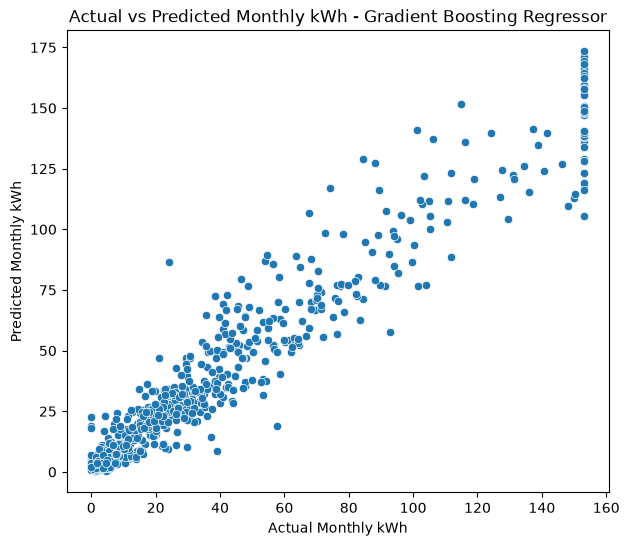

In [59]:
## Actual vs Predicted Plot

y_pred_best = best_model.predict(X_test)
y_pred_best = np.clip(y_pred_best, 0, None)

plt.figure(figsize=(7, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred_best
)

plt.title(f"Actual vs Predicted Monthly kWh - {best_model_name}")
plt.xlabel("Actual Monthly kWh")
plt.ylabel("Predicted Monthly kWh")

plt.show()

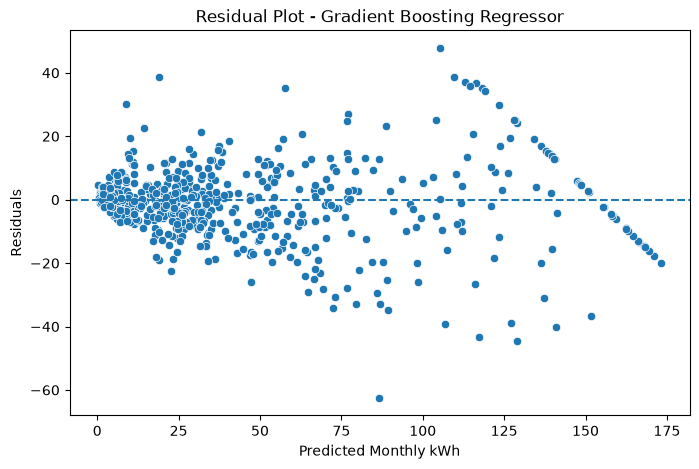

In [60]:
# Residual Plot

residuals = y_test - y_pred_best

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=y_pred_best,
    y=residuals
)

plt.axhline(0, linestyle='--')

plt.title(f"Residual Plot - {best_model_name}")
plt.xlabel("Predicted Monthly kWh")
plt.ylabel("Residuals")

plt.show()

,Feature,Importance
10,fan_energy_proxy,0.410697
2,daily_supply_hours,0.281202
6,fridge_count,0.076660
12,fridge_energy_proxy,0.067245
14,total_selected_appliances,0.031521
8,average_ac_usage_hours,0.026328
7,ac_count,0.025939
15,cooling_appliance_count,0.019028
13,ac_energy_proxy,0.016892
5,television_count,0.015910


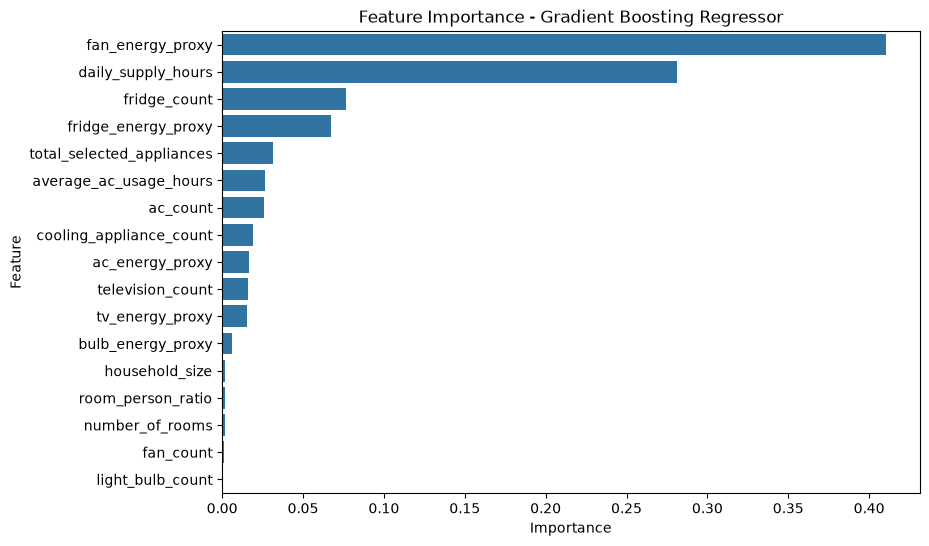

In [61]:
# Feature Importance

if hasattr(best_model, "feature_importances_"):
    feature_importance = pd.DataFrame({
        "Feature": model_features,
        "Importance": best_model.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    display(feature_importance)

    plt.figure(figsize=(9, 6))

    sns.barplot(
        data=feature_importance,
        x='Importance',
        y='Feature'
    )

    plt.title(f"Feature Importance - {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")

    plt.show()

else:
    print(f"{best_model_name} does not provide feature importance directly.")

##### Save Improved Model and Outputs

In [63]:
# Save Improved Model and Outputs

low_threshold = energy_df['estimated_monthly_kwh'].quantile(0.25)
moderate_threshold = energy_df['estimated_monthly_kwh'].quantile(0.50)
high_threshold = energy_df['estimated_monthly_kwh'].quantile(0.75)

category_thresholds = {
    "low_threshold": low_threshold,
    "moderate_threshold": moderate_threshold,
    "high_threshold": high_threshold
}

prediction_results = X_test.copy()
prediction_results['Actual_kWh'] = y_test
prediction_results['Predicted_kWh'] = y_pred_best
prediction_results['Difference'] = prediction_results['Actual_kWh'] - prediction_results['Predicted_kWh']

joblib.dump(best_model, MODEL_DIR / "energy_consumption_prediction_model.pkl")
joblib.dump(model_features, MODEL_DIR / "energy_model_features.pkl")
joblib.dump(best_model_name, MODEL_DIR / "best_model_name.pkl")
joblib.dump(category_thresholds, MODEL_DIR / "consumption_category_thresholds.pkl")

results_df.to_csv(
    DATA_DIR / "processed" / "supervised_model_comparison.csv",
    index=False
)

prediction_results.to_csv(
    DATA_DIR / "processed" / "supervised_prediction_results.csv",
    index=False
)

model_df.to_csv(
    DATA_DIR / "processed" / "energy_modelling_dataset.csv",
    index=False
)

print("Improved model and outputs saved successfully!")

Improved model and outputs saved successfully!
